# Логистическая регрессия: теория и практика

Логистическая регрессия — базовый алгоритм **бинарной классификации**:
несмотря на название "регрессия", она предсказывает не число, а вероятность
принадлежности к классу. Этот ноутбук — теоретический разбор на
синтетических данных, специально сгенерированных так, чтобы показать каждый
эффект изолированно.

**Прикладной разбор на реальных данных** (Titanic) — в
[`notebooks/01_titanic_eda.ipynb`](../notebooks/01_titanic_eda.ipynb) и
[`scripts/train_titanic.py`](../scripts/train_titanic.py). **Общая теория
линейных моделей** (МНК, градиентный спуск, регуляризация, диагностика) — в
[`tutorials/linearregression.ipynb`](../tutorials/linearregression.ipynb),
который стоит прочитать первым — логистическая регрессия унаследует оттуда
и градиентный спуск, и идею регуляризации.

**Содержание:**
1. От регрессии к классификации
2. Шансы (odds) и логит: откуда берётся именно эта функция (3 независимых обоснования)
3. Разделяющая граница (decision boundary)
4. Правдоподобие и log loss: полный вывод, выпуклость, численная устойчивость
5. Обучение: градиентный спуск, метод Ньютона / IRLS и солверы sklearn
6. Регуляризация
7. Метрики классификации и подбор порога
8. Многоклассовая классификация
9. Предположения и ограничения
10. Резюме

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs, make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, precision_recall_curve, auc,
)

from utils.plotting import set_style, CATEGORICAL_PALETTE, plot_confusion_matrix, plot_roc_curve

set_style()
rng = np.random.default_rng(42)

## 1. От регрессии к классификации

Почему нельзя просто взять линейную регрессию и предсказывать ей 0/1?
Попробуем в лоб:

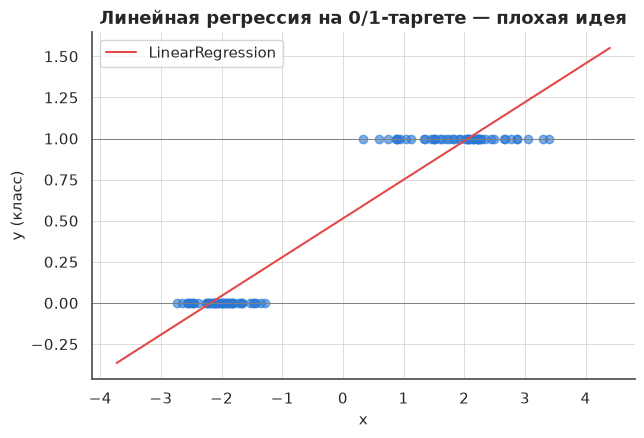

In [2]:
X_demo, y_demo = make_classification(
    n_samples=100, n_features=1, n_informative=1, n_redundant=0,
    n_clusters_per_class=1, class_sep=2.0, random_state=7,
)
x_demo = X_demo[:, 0]

from sklearn.linear_model import LinearRegression
lin_model = LinearRegression().fit(x_demo.reshape(-1, 1), y_demo)
x_grid = np.linspace(x_demo.min() - 1, x_demo.max() + 1, 200)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.scatter(x_demo, y_demo, alpha=0.6, color=CATEGORICAL_PALETTE[0])
ax.plot(x_grid, lin_model.predict(x_grid.reshape(-1, 1)), color=CATEGORICAL_PALETTE[3],
        label="LinearRegression")
ax.axhline(0, color="gray", linewidth=0.7); ax.axhline(1, color="gray", linewidth=0.7)
ax.set_xlabel("x"); ax.set_ylabel("y (класс)")
ax.legend(); ax.set_title("Линейная регрессия на 0/1-таргете — плохая идея")
plt.show()

Две проблемы сразу видны на графике:

1. Прямая уходит за пределы $[0, 1]$ — предсказание $\hat{y}=1.3$ или
   $\hat{y}=-0.2$ невозможно интерпретировать как вероятность.
2. Прямая линейно продолжает расти/падать за пределами облака точек — один
   очень "уверенный" выброс далеко справа или слева перекосит всю границу
   классов (в отличие от здоровой S-образной кривой, которая просто
   выходит на плато у 0 и 1).

Нужна функция, которая сжимает любое вещественное число в диапазон
$(0, 1)$, — это и есть сигмоида.

## 2. Шансы (odds) и логит: откуда берётся именно эта функция

Сигмоида — не случайный выбор "любой функции, которая сжимает числа в
$(0,1)$" (таких функций бесконечно много — годится CDF любого распределения).
У логистической регрессии есть три независимых обоснования именно этой
функции — с разных сторон приходят к одному и тому же результату.

### 2.1. Самое простое обоснование: от вероятности к шансам

Вероятность $p\in(0,1)$ неудобно моделировать линейно напрямую: линейная
функция $Xw$ пробегает всю числовую прямую, а $p$ обязана остаться в
$(0,1)$ при любых $X$ и $w$ — прямое равенство $p=Xw$ ломается на первом
же экстремальном $x$ (это мы и увидели на графике в разделе 1).

Стандартный статистический приём — перейти от $p$ к **шансам** (odds):

$$\text{odds} = \frac{p}{1-p}$$

Шансы показывают, во сколько раз событие "класс 1" вероятнее события
"класс 0": $p=0.5 \Rightarrow \text{odds}=1$ (равновероятно),
$p=0.9 \Rightarrow \text{odds}=9$ (в 9 раз вероятнее), $p\to1 \Rightarrow
\text{odds}\to\infty$. Шансы уже покрывают весь $(0,\infty)$ вместо
$(0,1)$ — прогресс, но всё ещё не вся числовая прямая (отрицательными
шансы быть не могут). Последний шаг — логарифм:

$$z = \ln(\text{odds}) = \ln\frac{p}{1-p} = \text{logit}(p)$$

Логарифм переводит $(0,\infty)$ в $(-\infty,\infty)$ — диапазон логита
теперь в точности совпадает с диапазоном линейной комбинации $Xw$. Именно
поэтому естественно поставить знак равенства между ними:

$$\text{logit}(p) = Xw
\quad\Longleftrightarrow\quad
p = \text{logit}^{-1}(Xw) = \frac{1}{1+e^{-Xw}} = \sigma(Xw)$$

**Сигмоида — это обратная функция к единственному "естественному"
преобразованию вероятности в число на всей числовой прямой**, а не
произвольный выбор. Отсюда же стандартная интерпретация коэффициентов:
увеличение $x_j$ на единицу прибавляет $w_j$ к логарифму шансов, то есть
умножает сами шансы на $e^{w_j}$.

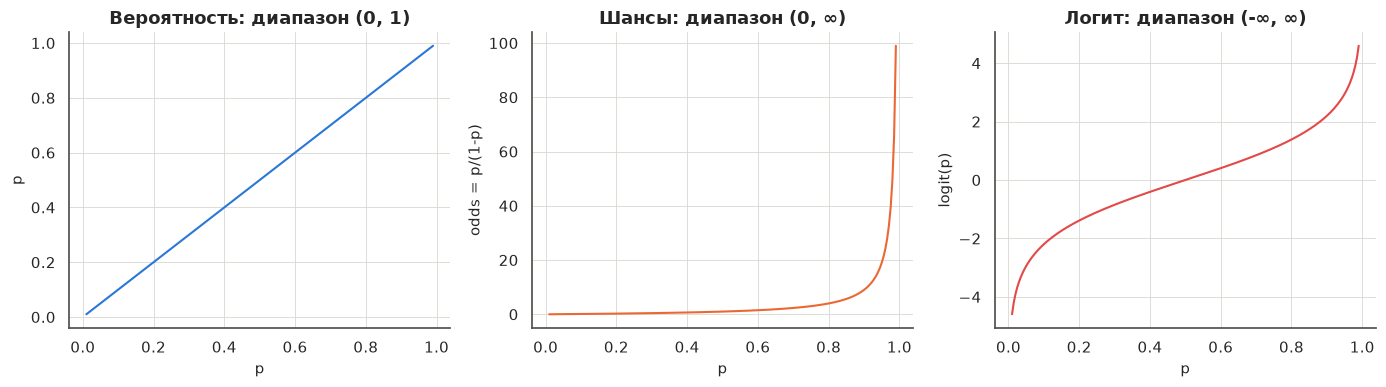

z              = [-3.   0.   2.5]
logit(sigmoid(z)) = [-3.   0.   2.5]


In [3]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def logit(p):
    return np.log(p / (1 - p))

p_grid = np.linspace(0.01, 0.99, 200)
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].plot(p_grid, p_grid, color=CATEGORICAL_PALETTE[0])
axes[0].set_xlabel("p"); axes[0].set_ylabel("p"); axes[0].set_title("Вероятность: диапазон (0, 1)")
axes[1].plot(p_grid, p_grid / (1 - p_grid), color=CATEGORICAL_PALETTE[1])
axes[1].set_xlabel("p"); axes[1].set_ylabel("odds = p/(1-p)"); axes[1].set_title("Шансы: диапазон (0, ∞)")
axes[2].plot(p_grid, logit(p_grid), color=CATEGORICAL_PALETTE[3])
axes[2].set_xlabel("p"); axes[2].set_ylabel("logit(p)"); axes[2].set_title("Логит: диапазон (-∞, ∞)")
fig.tight_layout()
plt.show()

# Проверка: logit и sigmoid - взаимно обратные функции
z_check = np.array([-3.0, 0.0, 2.5])
print("z              =", z_check)
print("logit(sigmoid(z)) =", logit(sigmoid(z_check)))  # должно совпасть с z_check

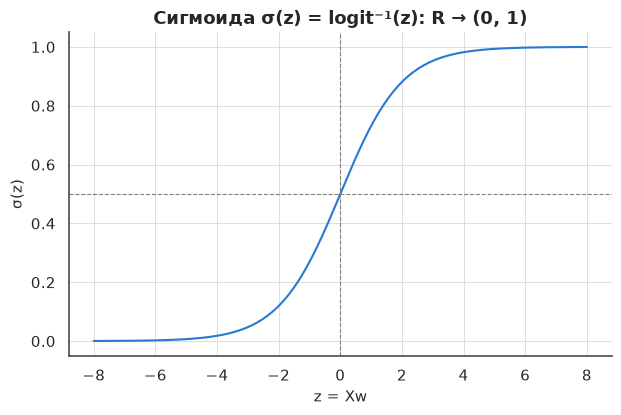

In [4]:
z_grid = np.linspace(-8, 8, 200)
fig, ax = plt.subplots(figsize=(7, 4.2))
ax.plot(z_grid, sigmoid(z_grid), color=CATEGORICAL_PALETTE[0])
ax.axhline(0.5, color="gray", linestyle="--", linewidth=0.8)
ax.axvline(0, color="gray", linestyle="--", linewidth=0.8)
ax.set_xlabel("z = Xw"); ax.set_ylabel("σ(z)")
ax.set_title("Сигмоида σ(z) = logit⁻¹(z): R → (0, 1)")
plt.show()

### 2.2. Более глубокое обоснование: скрытая переменная (latent variable model)

Первое обоснование было чисто функциональным ("удобно, потому что диапазоны
совпали"). Есть и содержательная мотивация. Представим, что за наблюдаемым
бинарным $y$ стоит ненаблюдаемая непрерывная величина $z^*$ — например,
"полезность" исхода 1 относительно исхода 0 или скрытый уровень риска:

$$z^* = Xw + \varepsilon, \qquad y = \begin{cases}1, & z^* > 0\\0, & z^*\le 0\end{cases}$$

Мы наблюдаем только знак зашумлённой линейной комбинации признаков, не её
точное значение. Тогда

$$P(y=1\mid x) = P(z^*>0) = P(\varepsilon>-Xw) = 1-F_\varepsilon(-Xw)$$

где $F_\varepsilon$ — функция распределения шума. Если $\varepsilon$ имеет
**логистическое распределение** (колоколообразное, симметричное, похожее
на нормальное, но с чуть более тяжёлыми хвостами), его CDF в точности
равна сигмоиде, и благодаря симметрии распределения
$1-F_\varepsilon(-z)=F_\varepsilon(z)=\sigma(z)$:

$$P(y=1\mid x) = \sigma(Xw)$$

То есть логистическая регрессия — это модель "скрытого порога": мы не
видим точное значение полезности/риска, только по какую сторону нуля она
оказалась. Так эту модель и вводят в эконометрике (модель дискретного
выбора, random utility model) — не как удобную формулу, а как явное
предположение о механизме, порождающем данные.

**Почему сигмоида, а не что-то ещё?** Если взять $\varepsilon$
**нормальным** вместо логистического, получится та же схема, но с
$F_\varepsilon=\Phi$ (CDF стандартного нормального распределения) —
это **probit-регрессия**, прямая альтернатива логистической.

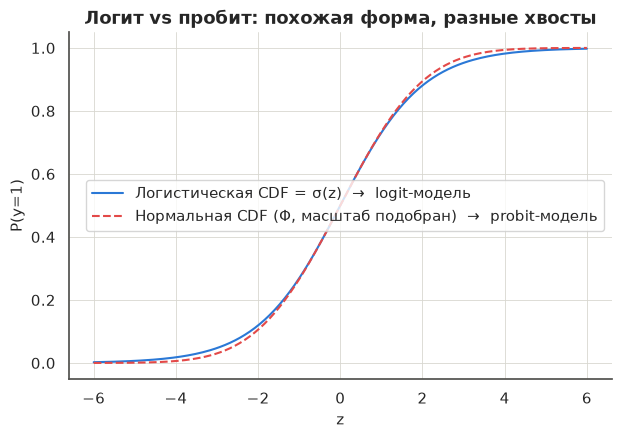

In [5]:
from scipy.stats import norm, logistic

z_grid = np.linspace(-6, 6, 200)
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(z_grid, logistic.cdf(z_grid), color=CATEGORICAL_PALETTE[0], label="Логистическая CDF = σ(z)  →  logit-модель")
ax.plot(z_grid, norm.cdf(z_grid, scale=1.6), color=CATEGORICAL_PALETTE[3], linestyle="--",
        label="Нормальная CDF (Φ, масштаб подобран)  →  probit-модель")
ax.set_xlabel("z"); ax.set_ylabel("P(y=1)")
ax.legend(); ax.set_title("Логит vs пробит: похожая форма, разные хвосты")
plt.show()

На графике обе кривые почти неотличимы в центре — и logit, и probit на
практике дают близкие предсказания. Разница — в инженерных удобствах
логистического распределения: сигмоида выражается в элементарных функциях,
а её производная — красивая замкнутая формула

$$\sigma'(z) = \sigma(z)\big(1-\sigma(z)\big)$$

(выведем и используем её в разделе 4), тогда как для probit нужна
производная CDF нормального распределения — сама плотность $\varphi(z)$,
которая не выражается в элементарных функциях и требует численного расчёта.
Отсюда и повсеместное предпочтение логит-модели в машинном обучении: та же
содержательная идея (скрытый порог), но с гораздо более дешёвой в
вычислении производной — а производная нужна на каждом шаге оптимизации.

### 2.3. Самое строгое обоснование: обобщённые линейные модели (GLM)

Третье обоснование — из статистической теории **обобщённых линейных
моделей** (Generalized Linear Models). GLM состоит из трёх частей:
(1) распределение $y$ из экспоненциального семейства, (2) линейный
предиктор $z=Xw$, (3) функция связи (link function) $g$, связывающая
среднее распределения с линейным предиктором: $g(E[y])=Xw$.

Для бинарного $y$ естественное распределение — **Бернулли**:
$P(y)=p^y(1-p)^{1-y}$. Запишем его в каноническом виде экспоненциального
семейства $P(y)=\exp(\eta\,y - A(\eta))$:

$$P(y) = p^y(1-p)^{1-y}
= \exp\Big(y\ln p + (1-y)\ln(1-p)\Big)
= \exp\Big(y\underbrace{\ln\frac{p}{1-p}}_{\eta} + \ln(1-p)\Big)$$

Естественный параметр (natural parameter) этого семейства — в точности
$\eta=\ln\frac{p}{1-p}=\text{logit}(p)$. Теория GLM предписывает
**канонический link** — функцию связи, равную естественному параметру:
$g(p)=\eta=Xw$. Для распределения Бернулли канонический link — это логит
и никакой другой; сигмоида как обратная к нему возникает не по вкусу
исследователя, а по структуре самого распределения Бернулли.

Это тот же механизм, что связывает разные регрессии в одно семейство:
гауссовский $y$ с identity link даёт обычную линейную регрессию, счётный
$y$ (число событий) с log link — Пуассоновскую регрессию, а Бернулли с
логит-link — логистическую (подробнее про GLM — в `questions.md`, раздел 8).
Это же наблюдение объясняет, почему градиент правдоподобия у логистической
и линейной регрессии выглядит настолько похоже — увидим в разделе 4.2.

## 3. Разделяющая граница (decision boundary)

На 2D-данных легко увидеть, что именно строит логистическая регрессия:
не кривую, разделяющую классы произвольно, а **прямую линию** (гиперплоскость
в общем случае) — там, где $\hat p = 0.5$, то есть $z = Xw = 0$.

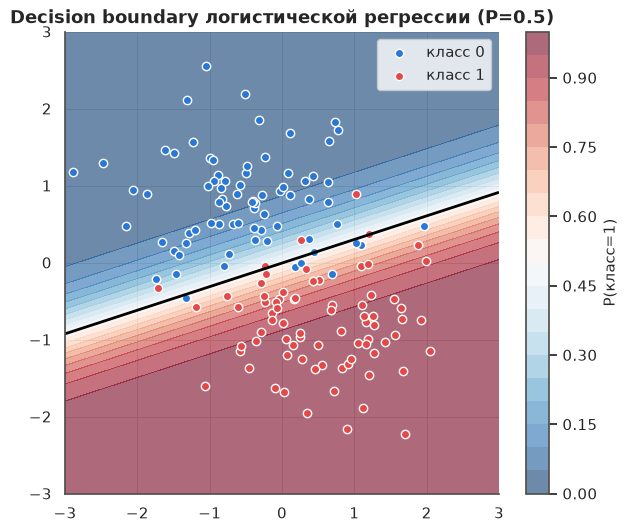

In [6]:
X_blob, y_blob = make_blobs(n_samples=150, centers=2, cluster_std=1.6, random_state=12)
scaler_blob = StandardScaler().fit(X_blob)
X_blob_scaled = scaler_blob.transform(X_blob)

clf = LogisticRegression().fit(X_blob_scaled, y_blob)

xx, yy = np.meshgrid(np.linspace(-3, 3, 300), np.linspace(-3, 3, 300))
grid_prob = clf.predict_proba(np.column_stack([xx.ravel(), yy.ravel()]))[:, 1].reshape(xx.shape)

fig, ax = plt.subplots(figsize=(7, 6))
contour = ax.contourf(xx, yy, grid_prob, levels=20, cmap="RdBu_r", alpha=0.6)
ax.contour(xx, yy, grid_prob, levels=[0.5], colors="black", linewidths=2)
ax.scatter(*X_blob_scaled[y_blob == 0].T, color=CATEGORICAL_PALETTE[0], edgecolor="white", label="класс 0")
ax.scatter(*X_blob_scaled[y_blob == 1].T, color=CATEGORICAL_PALETTE[3], edgecolor="white", label="класс 1")
fig.colorbar(contour, ax=ax, label="P(класс=1)")
ax.legend(); ax.set_title("Decision boundary логистической регрессии (P=0.5)")
plt.show()

Чёрная линия — граница решения $P=0.5$: она прямая, потому что
$z=Xw=0$ — это уравнение прямой (гиперплоскости) в пространстве признаков.
Это ключевое ограничение логистической регрессии: она умеет отделять только
**линейно разделимые** (или почти линейно разделимые) классы — как ансамбль
метода, добавление полиномиальных признаков (см. `tutorials/linearregression.ipynb`,
раздел 8) может сделать границу нелинейной, ровно как и в регрессии.

## 4. Правдоподобие и log loss: полный вывод

Почему для классификации не используют MSE? Если подставить $\hat p=\sigma(Xw)$
в MSE, функция потерь теряет выпуклость по $w$ — градиентный спуск может
застрять в локальном минимуме. Вместо этого используют **log loss**
(бинарную кросс-энтропию) — и в этом разделе выведем её не постулированием
формулы, а по шагам из принципа максимального правдоподобия (MLE),
докажем её выпуклость и разберём, почему её не считают "в лоб" на практике.

### 4.1. От вероятности одного наблюдения к правдоподобию выборки

Пусть $y_i\in\{0,1\}$ — метка, $\hat p_i=\sigma(x_iw)$ — предсказанная
моделью вероятность класса 1. Правдоподобие одного наблюдения — вероятность,
которую модель "поставила" на реально наблюдавшийся класс:

$$P(y_i\mid x_i) = \hat p_i^{\,y_i}(1-\hat p_i)^{\,1-y_i}$$

(при $y_i=1$ множитель $(1-\hat p_i)^0=1$ пропадает, остаётся $\hat p_i$;
при $y_i=0$ пропадает $\hat p_i^0=1$, остаётся $1-\hat p_i$ — удобная запись
"выключателем" сразу для обоих случаев одной формулой).

Если наблюдения независимы (то же стандартное предположение, что и в
Гаусса-Марков для линейной регрессии — `tutorials/linearregression.ipynb`),
совместное правдоподобие всей выборки — произведение вероятностей каждого
наблюдения:

$$L(w) = \prod_{i=1}^n P(y_i\mid x_i) = \prod_{i=1}^n \hat p_i^{\,y_i}(1-\hat p_i)^{\,1-y_i}$$

Максимизировать произведение из $n$ чисел, каждое $\le 1$, неудобно и
численно опасно: произведение стремительно уходит к нулю, теряя точность
float уже при паре сотен наблюдений. Логарифм — строго монотонное
преобразование (не меняет $\arg\max$), а произведение под ним превращается
в сумму:

$$\ell(w) = \ln L(w) = \sum_{i=1}^n\Big[y_i\ln\hat p_i + (1-y_i)\ln(1-\hat p_i)\Big]$$

Это **логарифм правдоподобия** (log-likelihood). Метод максимального
правдоподобия ищет $w^*=\arg\max_w \ell(w)$. Чтобы свести к привычной
задаче минимизации, меняем знак и усредняем по $n$ (усреднение не меняет
$\arg\min$, но делает масштаб независимым от размера выборки):

$$\mathcal{L}(w) = -\frac{1}{n}\ell(w)
= -\frac{1}{n}\sum_{i=1}^n\Big[y_i\ln\hat p_i+(1-y_i)\ln(1-\hat p_i)\Big]
\qquad\qquad
\arg\max_w \ell(w) = \arg\min_w \mathcal{L}(w)$$

Это в точности **log loss**: не отдельно придуманная "похожая на MSE, но
для вероятностей" формула, а negative log-likelihood по построению. В ML
эту же величину называют **бинарной кросс-энтропией** — оба названия
описывают одну и ту же формулу, пришедшую из разных областей (статистика
vs теория информации).

In [7]:
# Проверим утверждение численно: максимизация правдоподобия должна давать
# ровно те же веса, что и минимизация log loss (это одна и та же задача).
from scipy.optimize import minimize

def neg_log_likelihood(w, X_design, y):
    p_hat = sigmoid(X_design @ w)
    eps = 1e-12
    return -np.mean(y * np.log(p_hat + eps) + (1 - y) * np.log(1 - p_hat + eps))

X_design_blob = np.column_stack([np.ones(len(X_blob_scaled)), X_blob_scaled])
w0 = np.zeros(X_design_blob.shape[1])
result = minimize(neg_log_likelihood, w0, args=(X_design_blob, y_blob), method="BFGS")

sk_ref = LogisticRegression(C=np.inf).fit(X_blob_scaled, y_blob)
print(f"Минимизация -log-likelihood (scipy): {result.x.round(3)}")
print(f"sklearn LogisticRegression:          {np.r_[sk_ref.intercept_, sk_ref.coef_[0]].round(3)}")

Минимизация -log-likelihood (scipy): [-0.101  1.529 -6.086]
sklearn LogisticRegression:          [-0.098  1.523 -6.067]


Совпадает: minimize(-log-likelihood) и `LogisticRegression.fit` решают одну
и ту же задачу.

Посмотрим на форму штрафа $-\ln\hat p_i$ / $-\ln(1-\hat p_i)$ для одного
наблюдения:

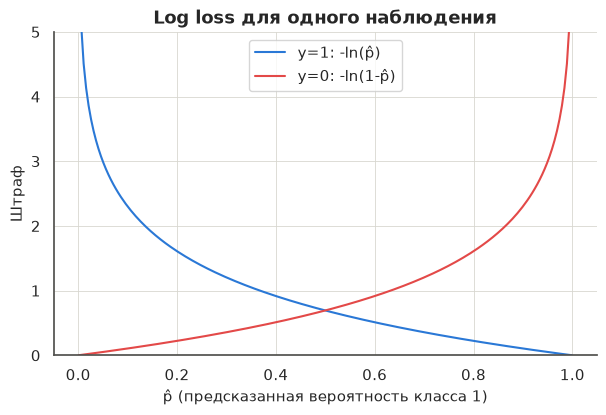

In [8]:
p_grid = np.linspace(0.001, 0.999, 200)
fig, ax = plt.subplots(figsize=(7, 4.2))
ax.plot(p_grid, -np.log(p_grid), color=CATEGORICAL_PALETTE[0], label="y=1: -ln(p̂)")
ax.plot(p_grid, -np.log(1 - p_grid), color=CATEGORICAL_PALETTE[3], label="y=0: -ln(1-p̂)")
ax.set_xlabel("p̂ (предсказанная вероятность класса 1)"); ax.set_ylabel("Штраф")
ax.legend(); ax.set_title("Log loss для одного наблюдения")
ax.set_ylim(0, 5)
plt.show()

Если истинный класс 1, а модель уверенно (близко к 0) предсказала
вероятность класса 1 — штраф улетает к бесконечности: log loss очень жёстко
наказывает **уверенные и неправильные** предсказания, в отличие от
осторожных ошибок около 0.5.

### 4.2. Вывод градиента

Производная здесь неочевидна с первого взгляда: $\hat p_i=\sigma(z_i)$,
$z_i=x_iw$ — нужно правило цепочки через $z_i$. Ключевой факт — производная
сигмоиды выражается через саму сигмоиду (проверим численно, чтобы не
поверить на слово):

In [9]:
def sigmoid_derivative_analytic(z):
    s = sigmoid(z)
    return s * (1 - s)

def sigmoid_derivative_numeric(z, h=1e-6):
    return (sigmoid(z + h) - sigmoid(z - h)) / (2 * h)

z_test = np.array([-2.0, -0.3, 0.0, 1.5, 3.0])
print("Аналитическая σ'(z) = σ(z)(1-σ(z)):", sigmoid_derivative_analytic(z_test).round(6))
print("Численная (конечные разности):     ", sigmoid_derivative_numeric(z_test).round(6))

Аналитическая σ'(z) = σ(z)(1-σ(z)): [0.104994 0.244458 0.25     0.149146 0.045177]
Численная (конечные разности):      [0.104994 0.244458 0.25     0.149146 0.045177]


Совпадает с точностью до ошибки округления конечных разностей — формула
$\sigma'(z)=\sigma(z)(1-\sigma(z))$ подтверждена. Теперь возьмём производную
вклада одного наблюдения в log-likelihood,
$\ell_i=y_i\ln\sigma(z_i)+(1-y_i)\ln(1-\sigma(z_i))$, по $w_j$
($z_i=x_iw$, $\partial z_i/\partial w_j = x_{ij}$):

$$\frac{\partial \ell_i}{\partial w_j}
= \left(\frac{y_i}{\sigma(z_i)} - \frac{1-y_i}{1-\sigma(z_i)}\right)\sigma'(z_i)\,x_{ij}$$

Подставляем $\sigma'(z_i)=\sigma(z_i)(1-\sigma(z_i))$ — дроби сокращаются:

$$\left(\frac{y_i}{\sigma(z_i)} - \frac{1-y_i}{1-\sigma(z_i)}\right)\sigma(z_i)(1-\sigma(z_i))
= y_i(1-\sigma(z_i)) - (1-y_i)\sigma(z_i) = y_i - \sigma(z_i)$$

Все "некрасивые" дроби исчезли:

$$\frac{\partial \ell_i}{\partial w_j} = (y_i-\hat p_i)\,x_{ij}
\quad\Longrightarrow\quad
\nabla_w\mathcal{L}(w) = \frac{1}{n}X^T(\hat p - y), \qquad \hat p=\sigma(Xw)$$

Это не совпадение и не просто "похоже на градиент MSE в линейной
регрессии" — это прямое следствие того, что логит является каноническим
link для распределения Бернулли (раздел 2.3): для **любой** GLM с
каноническим link градиент log-likelihood всегда принимает форму
$X^T(y-\hat\mu)$, где $\hat\mu$ — предсказанное среднее. Ровно так же
выглядел градиент MSE в линейной регрессии ($X^T(Xw-y)$,
`tutorials/linearregression.ipynb`, раздел 5) — оба являются частными
случаями одной и той же GLM-формулы, просто с разными $\hat\mu$
($\hat\mu=Xw$ для гауссовской модели, $\hat\mu=\sigma(Xw)$ для Бернулли).

### 4.3. Почему log loss выпукла: гессиан

Гладкости градиента мало — нужна выпуклость, чтобы градиентный спуск
(и любой другой локальный оптимизатор) не мог застрять в локальном
минимуме (тот же вопрос мы задавали для MSE в линейной регрессии,
`tutorials/linearregression.ipynb`, раздел 3). Продифференцируем градиент
$\nabla_w\mathcal L=\frac1n X^T(\sigma(Xw)-y)$ по $w$ ещё раз (снова
используя $\sigma'(z)=\sigma(z)(1-\sigma(z))$):

$$H = \nabla^2_w\mathcal{L}(w) = \frac{1}{n}X^TSX,
\qquad S = \text{diag}\big(\hat p_1(1-\hat p_1),\,\dots,\,\hat p_n(1-\hat p_n)\big)$$

$S$ — диагональная матрица с неотрицательными элементами ($p(1-p)\ge 0$
для любого $p\in[0,1]$, максимум $0.25$ при $p=0.5$), то есть $S$
положительно полуопределена. Тогда для любого вектора $v$:

$$v^THv = \frac{1}{n}v^TX^TSXv = \frac{1}{n}\big\|S^{1/2}Xv\big\|_2^2 \ge 0$$

$H$ положительно полуопределена **при любых** $w$ (не только в точке
минимума) — log loss выпукла на всей области определения, безусловно, в
отличие от MSE, применённого напрямую к $\sigma(Xw)$ (не выпукла).
Практическое следствие: какой бы оптимизатор ни использовался
(градиентный спуск, метод Ньютона из раздела 5.1, `lbfgs`), найденный
локальный минимум логистической регрессии — всегда глобальный.

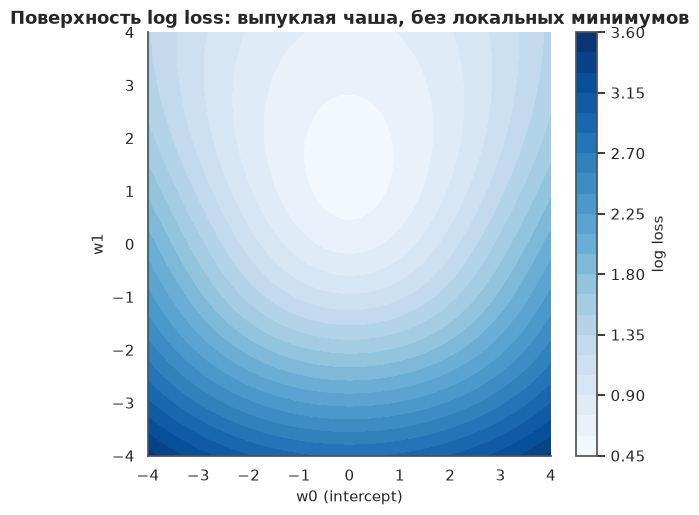

In [10]:
# Визуализация: поверхность log loss по двум весам - действительно похожа на чашу
w0_grid, w1_grid = np.meshgrid(np.linspace(-4, 4, 60), np.linspace(-4, 4, 60))
X_design_2d = np.column_stack([np.ones(len(X_blob_scaled)), X_blob_scaled[:, 0]])

loss_surface = np.zeros_like(w0_grid)
for i in range(w0_grid.shape[0]):
    for j in range(w0_grid.shape[1]):
        w_try = np.array([w0_grid[i, j], w1_grid[i, j]])
        loss_surface[i, j] = neg_log_likelihood(w_try, X_design_2d, y_blob)

fig, ax = plt.subplots(figsize=(6.5, 5.5))
contour = ax.contourf(w0_grid, w1_grid, loss_surface, levels=25, cmap="Blues")
fig.colorbar(contour, ax=ax, label="log loss")
ax.set_xlabel("w0 (intercept)"); ax.set_ylabel("w1")
ax.set_title("Поверхность log loss: выпуклая чаша, без локальных минимумов")
plt.show()

### 4.4. Инженерная деталь: почему log loss не считают "в лоб"

Наивная реализация — посчитать $\hat p=\sigma(z)$, затем
$-y\ln\hat p-(1-y)\ln(1-\hat p)$ — ломается на больших по модулю $z$:

In [11]:
z_extreme = -1000.0  # уверенное предсказание "класс 0" на объекте с истинным классом 1
p_naive = sigmoid(z_extreme)
print(f"σ({z_extreme}) = {p_naive}")               # underflow: округляется ровно до 0.0
print(f"-log(p_naive) = {-np.log(p_naive)}")        # log(0) = inf - "неопределённый" штраф

σ(-1000.0) = 0.0
-log(p_naive) = inf


/tmp/ipykernel_32735/1158951842.py:2: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))
/tmp/ipykernel_32735/423661269.py:4: RuntimeWarning: divide by zero encountered in log
  print(f"-log(p_naive) = {-np.log(p_naive)}")        # log(0) = inf - "неопределённый" штраф


Математически истинный штраф здесь конечен и равен примерно $1000$ (модель
очень уверенно ошиблась, но не бесконечно), а наивная формула из-за
арифметики float выдаёт `inf`. Проблема в том, что $\sigma(-1000)$ вычисляется
как ровно `0.0` (число слишком маленькое для float64), и логарифм нуля —
это `-inf`, хотя настоящий предел выражения $-\ln\sigma(z)$ при
$z\to-\infty$ конечен и растёт линейно по $|z|$.

Устойчивая формула переписывает log loss напрямую через $z$, минуя явное
вычисление $\sigma(z)$, через функцию **softplus** $=\ln(1+e^z)$:

$$-\ln\hat p_i = -\ln\sigma(z_i) = \ln(1+e^{-z_i})
\qquad
-\ln(1-\hat p_i) = \ln(1+e^{z_i})$$

Обе формулы для $y_i=1$ и $y_i=0$ объединяются в одну:

$$\ell_i = \ln(1+e^{z_i}) - y_i z_i = \text{softplus}(z_i) - y_i z_i$$

`numpy` считает $\ln(1+e^z)$ устойчиво через `np.logaddexp(0, z)`
(внутри — приём log-sum-exp: выносится $\max(0,z)$ до экспоненты, чтобы
никогда не считать $e^z$ для большого $z$ явно):

In [12]:
def log_loss_stable(z, y):
    return np.mean(np.logaddexp(0, z) - y * z)

z_arr = np.array([-1000.0, 1000.0])
y_arr = np.array([1.0, 0.0])  # оба - максимально "уверенно неправильные" предсказания

print("Наивная формула:  ", [-np.log(sigmoid(z)) if y == 1 else -np.log(1 - sigmoid(z))
                              for z, y in zip(z_arr, y_arr)])
print("Устойчивая формула:", [np.logaddexp(0, z) - y * z for z, y in zip(z_arr, y_arr)])

Наивная формула:   [np.float64(inf), np.float64(inf)]
Устойчивая формула: [np.float64(1000.0), np.float64(1000.0)]


/tmp/ipykernel_32735/1158951842.py:2: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))
/tmp/ipykernel_32735/3095546543.py:7: RuntimeWarning: divide by zero encountered in log
  print("Наивная формула:  ", [-np.log(sigmoid(z)) if y == 1 else -np.log(1 - sigmoid(z))


Наивная формула выдаёт `inf`/`nan` там, где устойчивая — корректные
конечные числа (~1000, то есть штраф действительно велик, но не
бесконечен). Именно поэтому промышленные реализации (включая
`sklearn.LogisticRegression`) никогда не считают log loss как буквальный
$-y\ln\hat p-(1-y)\ln(1-\hat p)$ — только через численно устойчивые
формулы вроде softplus/log-sum-exp.

## 5. Обучение: градиентный спуск, метод Ньютона / IRLS и солверы sklearn

Реализуем логистическую регрессию тем же способом, что линейную — через
градиентный спуск, — и сравним с `sklearn.LogisticRegression`.

In [13]:
class LogisticRegressionGD:
    def __init__(self, lr=0.5, n_iter=2000):
        self.lr, self.n_iter = lr, n_iter

    def fit(self, X, y):
        X_design = np.column_stack([np.ones(len(X)), X])
        w = np.zeros(X_design.shape[1])
        for _ in range(self.n_iter):
            p_hat = sigmoid(X_design @ w)
            grad = (1 / len(X)) * X_design.T @ (p_hat - y)
            w = w - self.lr * grad
        self.intercept_, self.coef_ = w[0], w[1:]
        return self

    def predict_proba(self, X):
        return sigmoid(self.intercept_ + X @ self.coef_)

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)


own_clf = LogisticRegressionGD().fit(X_blob_scaled, y_blob)
sk_clf = LogisticRegression(C=np.inf).fit(X_blob_scaled, y_blob)  # C=inf = без регуляризации, для честного сравнения

print(f"С нуля:  w={own_clf.coef_.round(3)}, b={own_clf.intercept_:.3f}")
print(f"sklearn: w={sk_clf.coef_[0].round(3)}, b={sk_clf.intercept_[0]:.3f}")
print(f"Accuracy с нуля: {(own_clf.predict(X_blob_scaled) == y_blob).mean():.4f}")
print(f"Accuracy sklearn: {sk_clf.score(X_blob_scaled, y_blob):.4f}")

С нуля:  w=[ 1.519 -6.033], b=-0.099
sklearn: w=[ 1.523 -6.067], b=-0.098
Accuracy с нуля: 0.9333
Accuracy sklearn: 0.9333


Веса и accuracy практически совпадают — разница объясняется тем, что
`sklearn` использует более точные численные оптимизаторы (см. ниже), а не
"наивный" градиентный спуск с фиксированным `lr`.

### 5.1. Метод Ньютона и IRLS: как это делают "по-настоящему" быстро

Градиентный спуск использует только первую производную и потому сходится
линейно — число верных цифр растёт примерно на константу за итерацию.
В разделе 4.3 мы уже вывели гессиан log loss, так что можно использовать
**метод Ньютона** — он учитывает кривизну функции потерь и сходится
квадратично (число верных цифр удваивается за итерацию):

$$w^{(t+1)} = w^{(t)} - H^{-1}\nabla_w\mathcal{L}(w^{(t)})
= w^{(t)} + (X^TSX)^{-1}X^T(y-\hat p)$$

где $S$ и $\hat p$ пересчитываются в точке $w^{(t)}$ на каждом шаге (в
отличие от линейной регрессии, где $X^TX$ не зависит от $w$ и решение
находится за один шаг — `tutorials/linearregression.ipynb`, раздел 3).

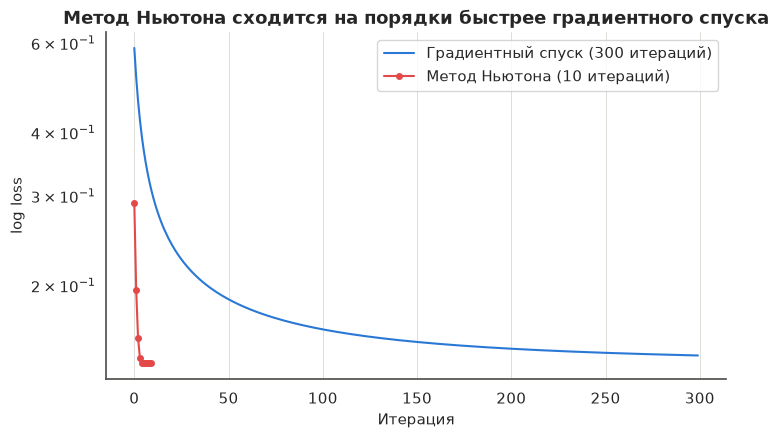

In [14]:
def gd_logreg_with_history(X, y, lr=0.5, n_iter=300):
    X_design = np.column_stack([np.ones(len(X)), X])
    w = np.zeros(X_design.shape[1])
    history = []
    for _ in range(n_iter):
        p_hat = sigmoid(X_design @ w)
        grad = (1 / len(X)) * X_design.T @ (p_hat - y)
        w = w - lr * grad
        history.append(neg_log_likelihood(w, X_design, y))
    return w, history

def newton_logreg(X, y, n_iter=10):
    X_design = np.column_stack([np.ones(len(X)), X])
    w = np.zeros(X_design.shape[1])
    history = []
    for _ in range(n_iter):
        p_hat = sigmoid(X_design @ w)
        grad = X_design.T @ (p_hat - y)               # без усреднения на 1/n - см. вывод в 4.2
        S = p_hat * (1 - p_hat)
        H = X_design.T @ (X_design * S[:, None])       # X^T S X без явной диагональной матрицы
        w = w - np.linalg.solve(H, grad)
        history.append(neg_log_likelihood(w, X_design, y))
    return w, history

_, loss_gd = gd_logreg_with_history(X_blob_scaled, y_blob, lr=0.5, n_iter=300)
_, loss_newton = newton_logreg(X_blob_scaled, y_blob, n_iter=10)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(loss_gd, color=CATEGORICAL_PALETTE[0], label=f"Градиентный спуск ({len(loss_gd)} итераций)")
ax.plot(loss_newton, color=CATEGORICAL_PALETTE[3], marker="o", ms=4,
        label=f"Метод Ньютона ({len(loss_newton)} итераций)")
ax.set_xlabel("Итерация"); ax.set_ylabel("log loss")
ax.set_yscale("log")
ax.legend(); ax.set_title("Метод Ньютона сходится на порядки быстрее градиентного спуска")
plt.show()

Метод Ньютона доходит до минимума за считанные итерации, тогда как
градиентному спуску нужны сотни шагов на тех же данных — плата за это:
метод Ньютона требует обращать $k\times k$ матрицу $H$ на каждом шаге
(дорого при большом числе признаков $k$), тогда как градиентный спуск
использует только $O(k)$ памяти и вычислений на шаг.

Такая же процедура в классической статистике называется **IRLS**
(Iteratively Reweighted Least Squares, "итеративно перевзвешенные наименьшие
квадраты"): можно показать, что обновление $w^{(t+1)}=w^{(t)}+(X^TSX)^{-1}X^T(y-\hat p)$
эквивалентно решению обычной взвешенной МНК-задачи с весами наблюдений $S$
и "скорректированным" таргетом $\tilde z = Xw^{(t)} + S^{-1}(y-\hat p)$ —
отсюда и название: на каждой итерации заново решается (Re-weighted) задача
наименьших квадратов (Least Squares). Это исторически первый способ обучения
логистической регрессии (до градиентного спуска и стохастических методов),
и он до сих пор используется внутри части солверов sklearn — см. ниже.

### Солверы sklearn

`LogisticRegression` в sklearn поддерживает несколько алгоритмов оптимизации
log loss — все они находят один и тот же глобальный минимум (функция
выпуклая), но с разной скоростью и разными требованиями к данным:

In [15]:
solvers = ["lbfgs", "liblinear", "saga"]
for solver in solvers:
    model = LogisticRegression(solver=solver, max_iter=2000, random_state=0)
    model.fit(X_blob_scaled, y_blob)
    print(f"{solver:>10}: accuracy={model.score(X_blob_scaled, y_blob):.4f}, "
          f"coef={model.coef_[0].round(3)}")

     lbfgs: accuracy=0.9200, coef=[ 1.033 -3.373]
 liblinear: accuracy=0.9200, coef=[ 1.033 -3.373]
      saga: accuracy=0.9200, coef=[ 1.033 -3.374]


- **`lbfgs`** (по умолчанию) — квазиньютоновский метод: **приближает**
  гессиан по истории последних градиентов, не вычисляя и не обращая его
  явно (как честный метод Ньютона из раздела 5.1) — почти такая же
  скорость сходимости, но $O(k)$ памяти вместо $O(k^2)$, поэтому годится и
  при большом числе признаков.
- **`newton-cg`, `newton-cholesky`** — честный метод Ньютона/IRLS из
  раздела 5.1, с разными способами решить линейную систему $Hv=
abla$ на
  каждом шаге (сопряжённые градиенты / разложение Холецкого). Быстрее всего
  сходится по числу итераций, но каждая итерация дороже.
- **`liblinear`** — покоординатный спуск (оптимизирует по одному весу за
  раз), эффективен на небольших датасетах и разреженных признаках.
- **`saga`** — стохастический градиентный спуск первого порядка (только
  градиент, без вторых производных), единственный из всех, кто
  масштабируется на очень большие датасеты и поддерживает
  ElasticNet-регуляризацию.

Все они находят один и тот же **глобальный** минимум (раздел 4.3
гарантирует это независимо от алгоритма) — выбор солвера в первую очередь
вопрос скорости и требований к памяти, а не качества результата.

## 6. Регуляризация в логистической регрессии

Как и в линейной регрессии (`tutorials/linearregression.ipynb`, раздел 10),
к log loss можно добавить L1/L2-штраф за большие веса. В sklearn сила
регуляризации задаётся параметром `C` — это **обратная** величина, то есть
`C` тем меньше, чем **сильнее** регуляризация (`C = 1/λ`).

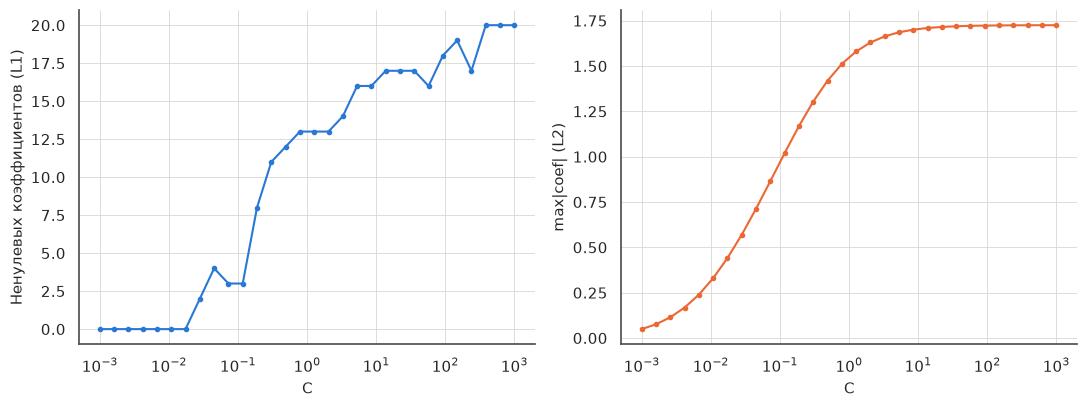

In [16]:
X_wide, y_wide = make_classification(
    n_samples=200, n_features=20, n_informative=4, n_redundant=4,
    random_state=1,
)
X_wide_scaled = StandardScaler().fit_transform(X_wide)

C_grid = np.logspace(-3, 3, 30)
n_nonzero_l1 = []
max_abs_coef_l2 = []
for C in C_grid:
    l1 = LogisticRegression(l1_ratio=1, solver="liblinear", C=C).fit(X_wide_scaled, y_wide)
    l2 = LogisticRegression(l1_ratio=0, C=C).fit(X_wide_scaled, y_wide)
    n_nonzero_l1.append(np.sum(np.abs(l1.coef_[0]) > 1e-4))
    max_abs_coef_l2.append(np.abs(l2.coef_[0]).max())

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].plot(C_grid, n_nonzero_l1, "-o", ms=3, color=CATEGORICAL_PALETTE[0])
axes[0].set_xscale("log"); axes[0].set_xlabel("C"); axes[0].set_ylabel("Ненулевых коэффициентов (L1)")
axes[1].plot(C_grid, max_abs_coef_l2, "-o", ms=3, color=CATEGORICAL_PALETTE[1])
axes[1].set_xscale("log"); axes[1].set_xlabel("C"); axes[1].set_ylabel("max|coef| (L2)")
fig.tight_layout()
plt.show()

При маленьком `C` (сильная регуляризация) L1 обнуляет почти все веса — как
и в Lasso для линейной регрессии (тот же геометрический эффект ромбовидной
области допустимых $w$). L2 не обнуляет веса, но сжимает их по модулю: чем
меньше `C`, тем меньше максимальный вес. Слишком маленький `C` — недообучение
(модель слишком ограничена); слишком большой `C` — модель приближается к
нерегуляризованной и рискует переобучиться, особенно на небольших выборках
с большим числом признаков (см. bias-variance tradeoff в
`tutorials/linearregression.ipynb`, раздел 9).

## 7. Метрики классификации

Обучим модель на данных с намеренно **несбалансированными классами**
(90%/10%) — на таких данных accuracy особенно обманчива.

In [17]:
X_imb, y_imb = make_classification(
    n_samples=1000, n_features=6, n_informative=4,
    weights=[0.9, 0.1], random_state=3,
)
X_tr, X_te, y_tr, y_te = train_test_split(X_imb, y_imb, test_size=0.3, stratify=y_imb, random_state=3)
scaler = StandardScaler().fit(X_tr)
clf_imb = LogisticRegression().fit(scaler.transform(X_tr), y_tr)

y_pred = clf_imb.predict(scaler.transform(X_te))
y_prob = clf_imb.predict_proba(scaler.transform(X_te))[:, 1]

print(f"Доля класса 1 в тесте: {y_te.mean():.1%}")
print(f"Accuracy константной модели 'всегда 0': {1 - y_te.mean():.4f}")
print(f"Accuracy обученной модели:              {accuracy_score(y_te, y_pred):.4f}")
print(f"Precision: {precision_score(y_te, y_pred):.4f}  Recall: {recall_score(y_te, y_pred):.4f}  "
      f"F1: {f1_score(y_te, y_pred):.4f}")

Доля класса 1 в тесте: 10.3%
Accuracy константной модели 'всегда 0': 0.8967
Accuracy обученной модели:              0.9067
Precision: 0.5484  Recall: 0.5484  F1: 0.5484


Accuracy обученной модели лишь немного лучше константной "всегда 0" — на
несбалансированных данных этого мало, чтобы судить о качестве. Нужны
**precision** (доля верных среди предсказанных положительными:
$\frac{TP}{TP+FP}$) и **recall** (доля найденных среди всех реально
положительных: $\frac{TP}{TP+FN}$) — они компромиссны: увеличивая порог
классификации, обычно повышаем precision ценой recall, и наоборот.

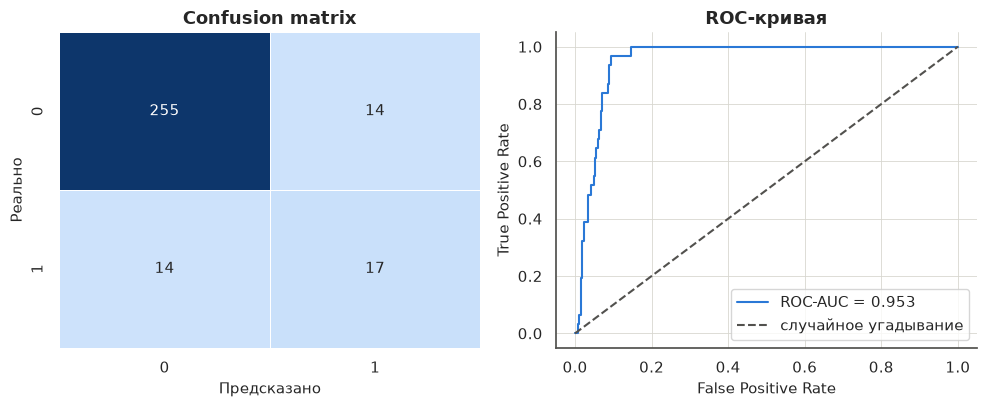

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
plot_confusion_matrix(y_te, y_pred, labels=("0", "1"), ax=axes[0])
plot_roc_curve(y_te, y_prob, ax=axes[1])
fig.tight_layout()
plt.show()

**ROC-AUC** — вероятность того, что случайно выбранный положительный объект
получит более высокую предсказанную вероятность, чем случайно выбранный
отрицательный. В отличие от accuracy, не зависит от порога классификации и
устойчив к дисбалансу классов — поэтому именно ROC-AUC (или PR-AUC при
сильном дисбалансе) обычно используют при сравнении моделей и подборе
гиперпараметров через кросс-валидацию (как в `scripts/train_titanic.py`).

### Подбор порога классификации

По умолчанию порог классификации — 0.5, но это не всегда оптимальный выбор:
если ошибки FP и FN "стоят" по-разному (например, в медицинской диагностике
пропустить болезнь обычно хуже, чем перестраховаться), порог стоит сдвинуть.

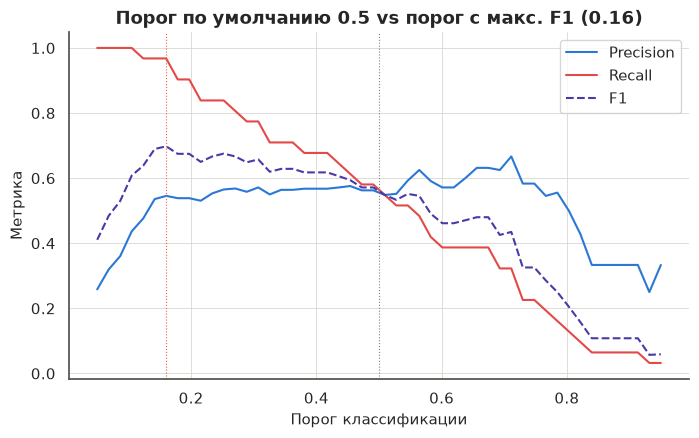

In [19]:
thresholds = np.linspace(0.05, 0.95, 50)
precisions, recalls, f1s = [], [], []
for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)
    precisions.append(precision_score(y_te, y_pred_t, zero_division=0))
    recalls.append(recall_score(y_te, y_pred_t, zero_division=0))
    f1s.append(f1_score(y_te, y_pred_t, zero_division=0))

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(thresholds, precisions, color=CATEGORICAL_PALETTE[0], label="Precision")
ax.plot(thresholds, recalls, color=CATEGORICAL_PALETTE[3], label="Recall")
ax.plot(thresholds, f1s, color=CATEGORICAL_PALETTE[4], label="F1", linestyle="--")
ax.axvline(0.5, color="gray", linewidth=0.8, linestyle=":")
best_t = thresholds[np.argmax(f1s)]
ax.axvline(best_t, color=CATEGORICAL_PALETTE[1], linewidth=0.8, linestyle=":")
ax.set_xlabel("Порог классификации"); ax.set_ylabel("Метрика")
ax.legend(); ax.set_title(f"Порог по умолчанию 0.5 vs порог с макс. F1 ({best_t:.2f})")
plt.show()

Precision растёт вместе с порогом (модель осторожнее назначает класс 1 —
среди тех немногих, кому назначила, ошибается реже), recall — падает
(пропускает всё больше настоящих положительных). Порог, максимизирующий F1
(гармоническое среднее precision и recall), не обязан совпадать со
"стандартным" 0.5 — особенно на несбалансированных данных, как здесь.

## 8. Многоклассовая классификация

Логистическая регрессия обобщается на $>2$ классов двумя способами:

- **One-vs-Rest (OvR)** — обучается $K$ независимых бинарных классификаторов
  "класс $k$ против всех остальных", предсказывается класс с наибольшей
  $\hat p_k$.
- **Multinomial (softmax)** — один классификатор сразу на все классы, вместо
  сигмоиды использует softmax: $\hat p_k = \dfrac{e^{z_k}}{\sum_j e^{z_j}}$ —
  честная многоклассовая вероятность, сумма по классам равна 1.

`sklearn.LogisticRegression` с `solver='lbfgs'` по умолчанию использует
multinomial-схему для многоклассовых задач.

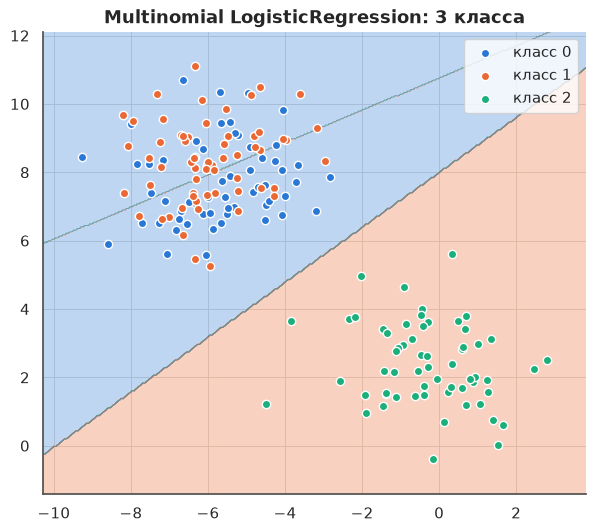

In [20]:
X_multi, y_multi = make_blobs(n_samples=180, centers=3, cluster_std=1.3, random_state=5)
clf_multi = LogisticRegression().fit(X_multi, y_multi)

xx, yy = np.meshgrid(np.linspace(X_multi[:, 0].min() - 1, X_multi[:, 0].max() + 1, 300),
                      np.linspace(X_multi[:, 1].min() - 1, X_multi[:, 1].max() + 1, 300))
zz = clf_multi.predict(np.column_stack([xx.ravel(), yy.ravel()])).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(7, 6))
ax.contourf(xx, yy, zz, alpha=0.3, colors=CATEGORICAL_PALETTE[:3])
for k, color in enumerate(CATEGORICAL_PALETTE[:3]):
    ax.scatter(*X_multi[y_multi == k].T, color=color, edgecolor="white", label=f"класс {k}")
ax.legend(); ax.set_title("Multinomial LogisticRegression: 3 класса")
plt.show()

Каждая пара классов по-прежнему разделена прямой линией — граница между
любыми двумя соседними областями линейна, просто теперь таких границ
несколько.

## 9. Предположения и ограничения

- **Линейная разделимость (в пространстве признаков).** Граница решения —
  всегда гиперплоскость; сильно нелинейные закономерности требуют
  полиномиальных/взаимодействующих признаков или другой модели.
- **Независимость наблюдений** и **отсутствие сильной мультиколлинеарности**
  — те же требования, что у линейной регрессии (раздел 4 и 11 в
  `tutorials/linearregression.ipynb`): коррелированные признаки делают
  коэффициенты неустойчивыми.
- **Чувствительность к масштабу признаков** — как и для градиентного спуска
  в линейной регрессии, признаки стоит стандартизировать (особенно важно
  при использовании регуляризации: без стандартизации штраф `C` по-разному
  "давит" на признаки с разным исходным масштабом).
- **Дисбаланс классов** — сам по себе не ломает обучение, но требует
  осторожности при выборе метрики (раздел 7) и, возможно, порога
  классификации или весов классов (`class_weight='balanced'`).

## 10. Резюме

- Сигмоида — не произвольная "функция для сжатия чисел", а обратная к
  логиту, естественному способу превратить вероятность $(0,1)$ в число на
  всей прямой (раздел 2.1); её же можно вывести из модели скрытого порога
  со случайным шумом (2.2) или как канонический link для распределения
  Бернулли в теории GLM (2.3) — три независимых пути к одной и той же
  формуле.
- Log loss — не отдельно придуманная формула "похожая на MSE, но для
  вероятностей", а negative log-likelihood по прямому построению из
  произведения вероятностей Бернулли (раздел 4.1); её градиент
  $X^T(\hat p-y)$ выводится явно через производную сигмоиды (4.2), а
  гессиан $X^TSX$ доказывает глобальную выпуклость (4.3) — гарантия того,
  что любой оптимизатор найдёт один и тот же минимум.
- log loss на практике считают не "в лоб", а через численно устойчивые
  softplus/log-sum-exp формулы (4.4) — иначе получаются `inf`/`nan` на
  уверенных предсказаниях.
- Обучают логистическую регрессию градиентным спуском (простой, но линейная
  сходимость) или методом Ньютона / IRLS (использует гессиан, сходится
  квадратично) — солверы sklearn (`lbfgs`, `newton-cg`/`newton-cholesky`,
  `saga`, `liblinear`) реализуют варианты и приближения обоих подходов
  (раздел 5).
- Регуляризация (L1/L2 через параметр `C`) работает так же, как в линейной
  регрессии: L1 обнуляет веса, L2 их сжимает.
- Accuracy — плохая метрика при дисбалансе классов; precision/recall/F1/
  ROC-AUC и подбор порога классификации дают куда более полную картину.
- Граница решения всегда линейна (гиперплоскость) — нелинейные
  зависимости требуют инженерии признаков.

**Прикладной пример** со всеми этими идеями на реальных данных — `Titanic`:
`notebooks/01_titanic_eda.ipynb` (разведочный анализ) и
`scripts/train_titanic.py` (полный пайплайн обучения с honest
baseline-vs-final сравнением).